# Specter Parser Lab
Production-oriented parsing laboratory for Pakistani legal judgments.
Each stage is isolated and measurable.

## 0. Configuration
Imports, paths, config, logging.

In [12]:
# Uncomment if running in Google Colab

!pip install -q pymupdf pdfplumber pandas matplotlib pillow tqdm rich
!pip install -q accelerate==1.12.0 albumentations==2.0.8 transformers==5.6.1 timm==1.0.22 open_clip_torch huggingface_hub sentencepiece einops


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
# TODO: Implement 0. Configuration
import fitz  # PyMuPDF
import pdfplumber
import json
import os
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

from rich import print
from rich.table import Table

In [2]:
# ==========================================================
# Configuration
# ==========================================================

ROOT_DIR = Path(r"d:\parsing_pipeline")
PDF_DIR = ROOT_DIR / "data" / "pdfs"
PDF_FILES = sorted(PDF_DIR.glob("*.pdf"))
if not PDF_FILES:
    raise FileNotFoundError(f"No PDFs found in {PDF_DIR}")

PDF_INDEX = 0
PDF_PATH = PDF_FILES[PDF_INDEX]
MODEL_ID = "nvidia/NVIDIA-Nemotron-Parse-v1.2"
TASK_PROMPT = "</s><s><predict_bbox><predict_classes><output_markdown><predict_no_text_in_pic>"
PAGE_DPI = 180

OUTPUT_DIR = ROOT_DIR / "artifacts" / "nemotron"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

SAVE_JSON = True
SAVE_MD = True

## 1. Load PDF
Load PDF and select pages.

In [3]:
# TODO: Implement 1. Load PDF
doc = fitz.open(PDF_PATH)

print(f"Pages : {doc.page_count}")
print(f"Metadata : {doc.metadata}")

Pages : 18

Metadata : {'format': 'PDF 1.3', 'title': '', 'author': '', 'subject': '', 'keywords': '', 'creator': 'Canon ', 
'producer': ' ', 'creationDate': "D:20140220120117+05'00'", 'modDate': '', 'trapped': '', 'encryption': None}

## 2. PDF Inspection
Determine digital/scanned/mixed with PyMuPDF metadata.

In [4]:
# TODO: Implement 2. PDF Inspection
def inspect_pdf(doc):

    report = {
        "pages": doc.page_count,
        "metadata": doc.metadata,
        "page_info": []
    }

    for i, page in enumerate(doc):

        d = page.get_text("dict")

        blocks = d["blocks"]

        images = page.get_images(full=True)

        fonts = set()

        span_count = 0

        char_count = 0

        for block in blocks:

            if block["type"] != 0:
                continue

            for line in block["lines"]:

                for span in line["spans"]:

                    fonts.add(span["font"])

                    span_count += 1

                    char_count += len(span["text"])

        page_info = {

            "page": i + 1,

            "width": page.rect.width,

            "height": page.rect.height,

            "text_characters": char_count,

            "text_spans": span_count,

            "images": len(images),

            "fonts": sorted(list(fonts))
        }

        report["page_info"].append(page_info)

    return report

In [5]:
report = inspect_pdf(doc)

print(report)

{
    'pages': 18,
    'metadata': {
        'format': 'PDF 1.3',
        'title': '',
        'author': '',
        'subject': '',
        'keywords': '',
        'creator': 'Canon ',
        'producer': ' ',
        'creationDate': "D:20140220120117+05'00'",
        'modDate': '',
        'trapped': '',
        'encryption': None
    },
    'page_info': [
        {
            'page': 1,
            'width': 607.3200073242188,
            'height': 941.760009765625,
            'text_characters': 251,
            'text_spans': 45,
            'images': 1,
            'fonts': ['Helvetica']
        },
        {
            'page': 2,
            'width': 606.5999755859375,
            'height': 939.9600219726562,
            'text_characters': 0,
            'text_spans': 0,
            'images': 1,
            'fonts': []
        },
        {
            'page': 3,
            'width': 605.1599731445312,
            'height': 939.5999755859375,
            'text_characters': 1263,
            'text_spans': 204,
            'images': 1,
            'fonts': ['Helvetica']
        },
        {
            'page': 4,
            'width': 608.760009765625,
            'height': 938.52001953125,
            'text_characters': 3,
            'text_spans': 1,
            'images': 1,
            'fonts': ['Helvetica']
        },
        {
            'page': 5,
            'width': 608.4000244140625,
            'height': 938.52001953125,
            'text_characters': 1374,
            'text_spans': 205,
            'images': 1,
            'fonts': ['Helvetica']
        },
        {
            'page': 6,
            'width': 605.8800048828125,
            'height': 938.1599731445312,
            'text_characters': 0,
            'text_spans': 0,
            'images': 1,
            'fonts': []
        },
        {
            'page': 7,
            'width': 606.239990234375,
            'height': 938.52001953125,
            'text_characters': 1199,
            'text_spans': 176,
            'images': 1,
            'fonts': ['Helvetica']
        },
        {
            'page': 8,
            'width': 608.0399780273438,
            'height': 938.1599731445312,
            'text_characters': 0,
            'text_spans': 0,
            'images': 1,
            'fonts': []
        },
        {
            'page': 9,
            'width': 607.3200073242188,
            'height': 939.5999755859375,
            'text_characters': 1715,
            'text_spans': 253,
            'images': 1,
            'fonts': ['Helvetica']
        },
        {
            'page': 10,
            'width': 606.5999755859375,
            'height': 938.52001953125,
            'text_characters': 0,
            'text_spans': 0,
            'images': 1,
            'fonts': []
        },
        {
            'page': 11,
            'width': 604.0800170898438,
            'height': 939.239990234375,
            'text_characters': 1469,
            'text_spans': 227,
            'images': 1,
            'fonts': ['Helvetica']
        },
        {
            'page': 12,
            'width': 609.47998046875,
            'height': 938.52001953125,
            'text_characters': 0,
            'text_spans': 0,
            'images': 1,
            'fonts': []
        },
        {
            'page': 13,
            'width': 608.4000244140625,
            'height': 938.8800048828125,
            'text_characters': 1680,
            'text_spans': 273,
            'images': 1,
            'fonts': ['Helvetica']
        },
        {
            'page': 14,
            'width': 605.8800048828125,
            'height': 937.7999877929688,
            'text_characters': 0,
            'text_spans': 0,
            'images': 1,
            'fonts': []
        },
        {
            'page': 15,
            'width': 608.4000244140625,
            'height': 939.239990234375,
            'text_characters': 1628,
            'text_spans': 233,
            'images': 1,
     

In [6]:
if SAVE_JSON:

    with open(OUTPUT_DIR / "pdf_inspection.json", "w", encoding="utf-8") as f:

        json.dump(report, f, indent=4, ensure_ascii=False)

print("Saved.")

Saved.

In [7]:
table = Table(title="PDF Inspection")

table.add_column("Page")
table.add_column("Chars")
table.add_column("Spans")
table.add_column("Images")

for p in report["page_info"]:

    table.add_row(
        str(p["page"]),
        str(p["text_characters"]),
        str(p["text_spans"]),
        str(p["images"])
    )

print(table)

         PDF Inspection          
┏━━━━━━┳━━━━━━━┳━━━━━━━┳━━━━━━━━┓
┃ Page ┃ Chars ┃ Spans ┃ Images ┃
┡━━━━━━╇━━━━━━━╇━━━━━━━╇━━━━━━━━┩
│ 1    │ 251   │ 45    │ 1      │
│ 2    │ 0     │ 0     │ 1      │
│ 3    │ 1263  │ 204   │ 1      │
│ 4    │ 3     │ 1     │ 1      │
│ 5    │ 1374  │ 205   │ 1      │
│ 6    │ 0     │ 0     │ 1      │
│ 7    │ 1199  │ 176   │ 1      │
│ 8    │ 0     │ 0     │ 1      │
│ 9    │ 1715  │ 253   │ 1      │
│ 10   │ 0     │ 0     │ 1      │
│ 11   │ 1469  │ 227   │ 1      │
│ 12   │ 0     │ 0     │ 1      │
│ 13   │ 1680  │ 273   │ 1      │
│ 14   │ 0     │ 0     │ 1      │
│ 15   │ 1628  │ 233   │ 1      │
│ 16   │ 0     │ 0     │ 1      │
│ 17   │ 215   │ 41    │ 1      │
│ 18   │ 0     │ 0     │ 1      │
└──────┴───────┴───────┴────────┘

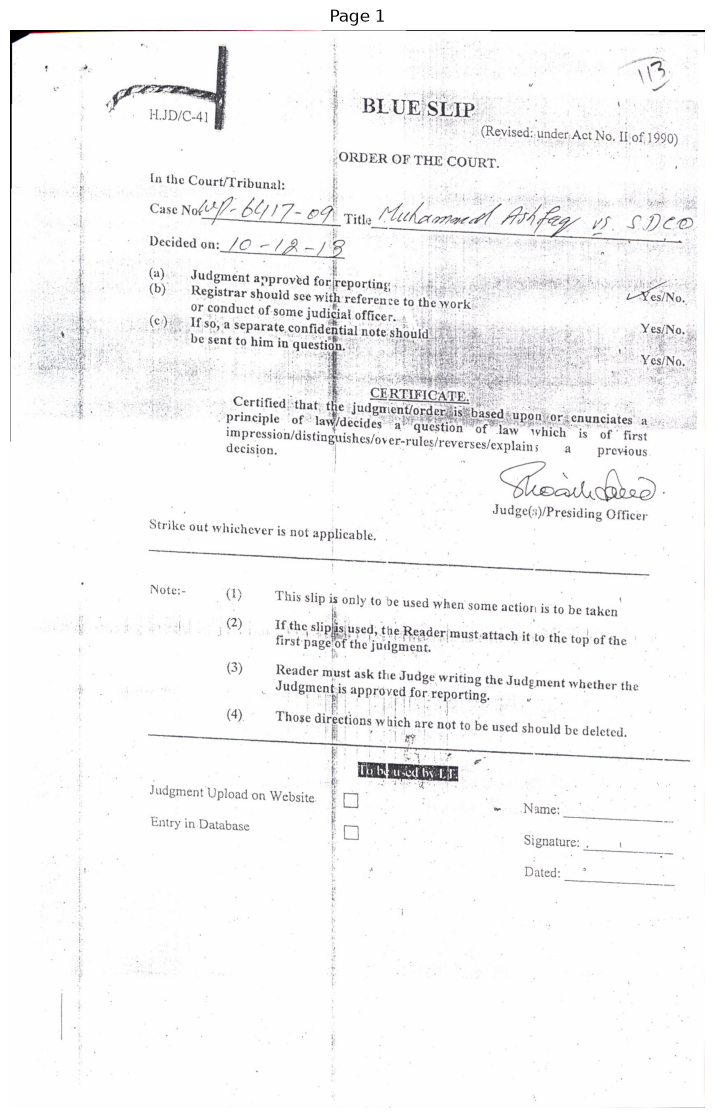

In [8]:
PAGE = 0

page = doc[PAGE]

pix = page.get_pixmap(dpi=200)

img = Image.frombytes(
    "RGB",
    [pix.width, pix.height],
    pix.samples
)

plt.figure(figsize=(10,14))
plt.imshow(img)
plt.axis("off")
plt.title(f"Page {PAGE+1}")
plt.show()

## 12. Nemotron Parse Run
Load NVIDIA Nemotron Parse v1.2, run it page by page, visualize the page overlays, and export the final JSON and Markdown artifacts.

In [ ]:
import importlib.util
import sys
from pathlib import Path

import fitz
import matplotlib.pyplot as plt
import torch
from huggingface_hub import snapshot_download
from IPython.display import display
from PIL import Image, ImageDraw, ImageFont
from transformers import AutoModel, AutoProcessor, AutoTokenizer, GenerationConfig

hf_token = os.environ.get("HF_API_KEY") or os.environ.get("HUGGINGFACE_HUB_TOKEN")

def render_page_image(page, dpi=180):
    pix = page.get_pixmap(matrix=fitz.Matrix(dpi / 72, dpi / 72), alpha=False)
    return Image.frombytes("RGB", [pix.width, pix.height], pix.samples)

def fit_image_for_model(image, max_size=(1664, 2048)):
    fitted = image.copy()
    fitted.thumbnail(max_size, Image.Resampling.LANCZOS)
    return fitted

def color_for_class(label):
    palette = ["#ff6b6b", "#4dabf7", "#51cf66", "#ffd43b", "#845ef7", "#ff922b", "#20c997", "#f06595"]
    return palette[abs(hash(label)) % len(palette)]

def load_postprocessing_module(repo_dir):
    repo_dir = Path(repo_dir)
    if str(repo_dir) not in sys.path:
        sys.path.insert(0, str(repo_dir))
    postprocessing_candidates = list(repo_dir.rglob("postprocessing.py"))
    if not postprocessing_candidates:
        raise FileNotFoundError("Could not find postprocessing.py in the downloaded model snapshot.")
    postprocessing_path = postprocessing_candidates[0]
    spec = importlib.util.spec_from_file_location("nemotron_postprocessing", postprocessing_path)
    module = importlib.util.module_from_spec(spec)
    assert spec.loader is not None
    spec.loader.exec_module(module)
    return module

device = "cuda" if torch.cuda.is_available() else "cpu"
dtype = torch.bfloat16 if device == "cuda" else torch.float32

print(f"Using device: {device}")
print(f"PDF: {PDF_PATH}")
print(f"Output dir: {OUTPUT_DIR}")

local_model_dir = snapshot_download(repo_id=MODEL_ID, repo_type="model", token=hf_token)

model = AutoModel.from_pretrained(local_model_dir, trust_remote_code=True, torch_dtype=dtype)
if device == "cuda":
    model = model.to(device)
model.eval()

processor = AutoProcessor.from_pretrained(local_model_dir, trust_remote_code=True, token=hf_token)
tokenizer = AutoTokenizer.from_pretrained(local_model_dir, token=hf_token)
generation_config = GenerationConfig.from_pretrained(local_model_dir, trust_remote_code=True, token=hf_token)
generation_config.max_new_tokens = 9000
generation_config.do_sample = False
generation_config.temperature = 0.0
generation_config.top_k = 1
generation_config.repetition_penalty = 1.1

postprocessing = load_postprocessing_module(local_model_dir)

pdf_doc = fitz.open(PDF_PATH)
page_records = []
markdown_pages = []

for page_index in range(pdf_doc.page_count):
    page = pdf_doc[page_index]
    page_image = fit_image_for_model(render_page_image(page, dpi=PAGE_DPI))
    inputs = processor(images=[page_image], text=TASK_PROMPT, return_tensors="pt", add_special_tokens=False)
    inputs = {key: value.to(device) for key, value in inputs.items()}

    with torch.inference_mode():
        outputs = model.generate(**inputs, generation_config=generation_config)

    generated_text = processor.batch_decode(outputs, skip_special_tokens=True)[0]

    try:
        classes, bboxes, texts = postprocessing.extract_classes_bboxes(generated_text)
        bboxes = [postprocessing.transform_bbox_to_original(bbox, page_image.width, page_image.height) for bbox in bboxes]
        texts = [
            postprocessing.postprocess_text(
                text,
                cls=cls,
                table_format="markdown",
                text_format="markdown",
                blank_text_in_figures=False,
            )
            for text, cls in zip(texts, classes)
        ]
        parsed_ok = True
        parse_error = None
    except Exception as exc:
        classes, bboxes, texts = [], [], []
        parsed_ok = False
        parse_error = str(exc)

    page_record = {
        "page": page_index + 1,
        "image_size": [page_image.width, page_image.height],
        "parsed_ok": parsed_ok,
        "parse_error": parse_error,
        "generated_text": generated_text,
        "classes": classes,
        "bboxes": bboxes,
        "texts": texts,
    }
    page_records.append(page_record)
    markdown_pages.append(f"## Page {page_index + 1}\n\n" + ("\n\n".join(texts) if texts else generated_text))

    overlay = page_image.copy()
    draw = ImageDraw.Draw(overlay)
    font = ImageFont.load_default()
    for cls, bbox, text in zip(classes, bboxes, texts):
        if not bbox or len(bbox) != 4:
            continue
        color = color_for_class(cls)
        draw.rectangle(bbox, outline=color, width=3)
        label = f"{cls}: {text[:60]}" if text else cls
        text_bbox = draw.textbbox((0, 0), label, font=font)
        label_height = text_bbox[3] - text_bbox[1] + 6
        label_width = text_bbox[2] - text_bbox[0] + 8
        x0, y0, x1, y1 = bbox
        label_y = max(0, y0 - label_height)
        draw.rectangle([x0, label_y, min(page_image.width, x0 + label_width), y0], fill=color)
        draw.text((x0 + 4, label_y + 2), label, fill="white", font=font)

    fig, ax = plt.subplots(figsize=(12, 16))
    ax.imshow(overlay)
    ax.set_title(f"Nemotron Parse - Page {page_index + 1}")
    ax.axis("off")
    plt.show()

document_output = {
    "model_id": MODEL_ID,
    "prompt": TASK_PROMPT,
    "source_pdf": str(PDF_PATH),
    "pages": page_records,
}

doc_name = PDF_PATH.stem
json_path = OUTPUT_DIR / f"{doc_name}_nemotron.json"
md_path = OUTPUT_DIR / f"{doc_name}_nemotron.md"

if SAVE_JSON:
    with open(json_path, "w", encoding="utf-8") as f:
        json.dump(document_output, f, indent=2, ensure_ascii=False)

if SAVE_MD:
    with open(md_path, "w", encoding="utf-8") as f:
        f.write("\n\n".join(markdown_pages))

print(f"Saved JSON to: {json_path}")
print(f"Saved MD to: {md_path}")

c:\Users\shamo\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cpu

PDF: d:\parsing_pipeline\data\pdfs\2013LHC4394.pdf

Output dir: d:\parsing_pipeline\artifacts\nemotron

Fetching 32 files:   0%|          | 0/32 [00:00<?, ?it/s]

## 3. Native Text Extraction
Extract spans, glyphs, fonts, bboxes.

# 3. RTL Text Analysis and Bidirectional Correction

In [ ]:
import json
from bidi.algorithm import get_display
from rich.table import Table
from rich import print

def get_script_type(char):
    if not char or not char.strip():
        return "SPACE"
    cp = ord(char)
    # Arabic, Arabic Supplement, Arabic Extended-A, Arabic Presentation Forms-A, Arabic Presentation Forms-B
    if (0x0600 <= cp <= 0x06FF or 
        0x0750 <= cp <= 0x077F or 
        0x08A0 <= cp <= 0x08FF or 
        0xFB50 <= cp <= 0xFDFF or 
        0xFE70 <= cp <= 0xFEFF):
        return "RTL"
    if 0x0000 <= cp <= 0x024F:
        if char.isdigit():
            return "NUM"
        return "LTR"
    return "OTHER"

In [ ]:
def extract_and_correct_runs(line_chars):
    runs = []
    current_run_chars = []
    current_script = None
    
    for char_info in line_chars:
        char = char_info.get("char", "")
        script = get_script_type(char)
        
        if script == "SPACE":
            if current_script is not None:
                current_run_chars.append(char_info)
            continue
            
        if script != current_script:
            if current_run_chars:
                runs.append({"script": current_script, "chars": current_run_chars})
            current_script = script
            current_run_chars = [char_info]
        else:
            current_run_chars.append(char_info)
            
    if current_run_chars:
        runs.append({"script": current_script, "chars": current_run_chars})
        
    corrected_runs = []
    contains_rtl = False
    needs_bidi = False
    
    char_index_offset = 0
    
    for run in runs:
        script = run["script"]
        chars = run["chars"]
        text = "".join(c.get("char", "") for c in chars)
        
        run_length = len(text)
        char_start = char_index_offset
        char_end = char_index_offset + run_length
        char_index_offset = char_end
        
        bboxes = [c.get("bbox", []) for c in chars if c.get("bbox")]
        if bboxes:
            min_x = min(b[0] for b in bboxes)
            min_y = min(b[1] for b in bboxes)
            max_x = max(b[2] for b in bboxes)
            max_y = max(b[3] for b in bboxes)
            run_bbox = [min_x, min_y, max_x, max_y]
        else:
            run_bbox = []
        
        is_visual = False
        corrected_text = text
        
        if script == "RTL":
            contains_rtl = True
            non_space = [c for c in chars if c.get("char", "").strip()]
            if len(non_space) > 1:
                first_x = non_space[0].get("bbox", [0])[0]
                last_x = non_space[-1].get("bbox", [0])[0]
                is_visual = first_x < last_x
            elif len(non_space) == 1:
                is_visual = True
                
            if is_visual:
                needs_bidi = True
                corrected_text = get_display(text)
                
        corrected_runs.append({
            "script": script,
            "original_text": text,
            "corrected_text": corrected_text,
            "is_visual_order": is_visual if script == "RTL" else None,
            "char_start": char_start,
            "char_end": char_end,
            "bbox": run_bbox
        })
        
    return corrected_runs, contains_rtl, needs_bidi

In [ ]:
def process_glyph_document(glyph_doc):
    enriched_pages = []
    total_lines = 0
    rtl_lines = 0
    corrected_lines = 0
    
    for page in glyph_doc.get("pages", []):
        enriched_page = dict(page)
        enriched_page["blocks"] = []
        for block in page.get("blocks", []):
            enriched_block = dict(block)
            enriched_lines = []
            
            for line in block.get("lines", []):
                total_lines += 1
                line_chars = []
                for span in line.get("spans", []):
                    line_chars.extend(span.get("chars", []))
                    
                original_text = "".join(c.get("char", "") for c in line_chars)
                runs, contains_rtl, needs_bidi = extract_and_correct_runs(line_chars)
                
                corrected_text = "".join(r["corrected_text"] for r in runs)
                
                if contains_rtl: rtl_lines += 1
                if needs_bidi: corrected_lines += 1
                
                rtl_run_count = sum(1 for r in runs if r["script"] == "RTL")
                mixed_script = len(set(r["script"] for r in runs if r["script"] not in ("SPACE", "OTHER"))) > 1
                
                simple_runs = [{
                    "script": r["script"], 
                    "text": r["corrected_text"],
                    "char_start": r["char_start"],
                    "char_end": r["char_end"],
                    "bbox": r["bbox"]
                } for r in runs]
                
                enriched_line = dict(line)
                enriched_line["original_text"] = original_text
                enriched_line["corrected_text"] = corrected_text
                enriched_line["script_runs"] = simple_runs
                
                confidence_score = 0.97 if contains_rtl else 1.0
                enriched_line["confidence"] = {
                    "contains_rtl": contains_rtl,
                    "needs_bidi": needs_bidi,
                    "rtl_run_count": rtl_run_count,
                    "mixed_script": mixed_script,
                    "confidence": confidence_score
                }
                
                enriched_lines.append(enriched_line)
            enriched_block["lines"] = enriched_lines
            enriched_page["blocks"].append(enriched_block)
        enriched_pages.append(enriched_page)
        
    stats = {
        "total_lines": total_lines,
        "rtl_lines": rtl_lines,
        "corrected_lines": corrected_lines
    }
    
    enriched_doc = dict(glyph_doc)
    enriched_doc["pages"] = enriched_pages
    return enriched_doc, stats

if 'glyph_document' not in locals() and 'glyph_document' not in globals():
    try:
        with open("outputs/glyph_document.json", "r", encoding="utf-8") as f:
            glyph_document = json.load(f)
    except FileNotFoundError:
        print("glyph_document not found in outputs/")

if 'glyph_document' in locals() or 'glyph_document' in globals():
    enriched_document, processing_stats = process_glyph_document(glyph_document)

In [ ]:
if 'processing_stats' in locals():
    print(f"Total Lines Processed: {processing_stats['total_lines']}")
    print(f"Lines containing RTL: {processing_stats['rtl_lines']}")
    print(f"Lines corrected: {processing_stats['corrected_lines']}")

    table = Table(title="RTL Text Analysis & Correction (Sample)")
    table.add_column("Original (Visual)")
    table.add_column("Corrected (Logical)")
    table.add_column("Needs Bidi")
    table.add_column("Script Runs")

    displayed = 0
    for page in enriched_document.get("pages", []):
        for block in page.get("blocks", []):
            for line in block.get("lines", []):
                if line.get("contains_rtl") and displayed < 10:
                    run_summary = ", ".join(r["script"] for r in line["script_runs"] if r["script"] != "SPACE")
                    table.add_row(
                        line["original_text"],
                        line["corrected_text"],
                        str(line.get("needs_bidi")),
                        run_summary
                    )
                    displayed += 1

    print(table)

In [ ]:
if 'enriched_document' in locals():
    with open("outputs/bidi_corrected_document.json", "w", encoding="utf-8") as f:
        json.dump(enriched_document, f, indent=4, ensure_ascii=False)
    print("Enriched document exported to outputs/bidi_corrected_document.json")

### Mixed Script Validation

In [ ]:
# Validate Mixed Scripts
dummy_mixed = "Section 302 PPC کے تحت"
dummy_chars = []
x = 0
for char in dummy_mixed:
    dummy_chars.append({"char": char, "bbox": [x, 0, x+10, 10]})
    x += 10 # simulated LTR visual order (but in reality the Urdu might be RTL)

runs, cr, nb = extract_and_correct_runs(dummy_chars)
print("Mixed String Original:", dummy_mixed)
for r in runs:
    print(f"[{r['script']}] '{r['original_text']}' -> '{r['corrected_text']}' | BBox: {r.get('bbox')} | chars: {r.get('char_start')}-{r.get('char_end')}")

assert any(r['script'] == 'LTR' and "Section 302 PPC" in r['original_text'] for r in runs), "English intact check failed"
assert any(r['script'] == 'RTL' for r in runs), "Urdu run check failed"
print("Mixed line validation passed!")

### Character Coordinates Visualization

In [ ]:
import matplotlib.pyplot as plt

def visualize_rtl_line(glyph_doc):
    target_line = None
    for page in glyph_doc.get("pages", []):
        for block in page.get("blocks", []):
            for line in block.get("lines", []):
                chars = []
                for span in line.get("spans", []):
                    chars.extend(span.get("chars", []))
                
                text = "".join(c.get("char", "") for c in chars)
                if any(get_script_type(c) == "RTL" for c in text):
                    target_line = chars
                    break
            if target_line: break
        if target_line: break

    if not target_line:
        print("No RTL line found for visualization.")
        return

    x_coords = []
    y_coords = []
    indices = []
    labels = []

    for i, char_info in enumerate(target_line):
        char = char_info.get("char", "").strip()
        bbox = char_info.get("bbox")
        if char and bbox:
            x_coords.append(bbox[0]) # min x
            y_coords.append(bbox[1]) # min y
            indices.append(i)
            labels.append(char)

    plt.figure(figsize=(12, 4))
    plt.scatter(indices, x_coords, color='blue', label='X Coordinate')
    
    for i, txt in enumerate(labels):
        plt.annotate(txt, (indices[i], x_coords[i]), textcoords="offset points", xytext=(0,10), ha='center')
        
    plt.xlabel("Character Index (Reading Order from PDF)")
    plt.ylabel("X Coordinate")
    plt.title("Visual vs Logical Order (X-Coord by Index)")
    plt.legend()
    plt.grid(True)
    plt.show()

if 'glyph_document' in locals() or 'glyph_document' in globals():
    visualize_rtl_line(glyph_document)

### Ground Truth Comparison (CER / WER)

In [ ]:
import jiwer

def compute_iou(boxA, boxB):
    # box is [x_min, y_min, x_max, y_max] or similar
    # if box format is different, adapt. 
    # Let's assume standard [x0, y0, x1, y1] for pipeline.
    # For GT, we need to convert dict to list.
    
    gt_x0 = boxA.get('x', 0)
    gt_y0 = boxA.get('y', 0)
    gt_x1 = gt_x0 + boxA.get('w', 0)
    gt_y1 = gt_y0 + boxA.get('h', 0)
    
    pipe_x0, pipe_y0, pipe_x1, pipe_y1 = boxB
    
    inter_x0 = max(gt_x0, pipe_x0)
    inter_y0 = max(gt_y0, pipe_y0)
    inter_x1 = min(gt_x1, pipe_x1)
    inter_y1 = min(gt_y1, pipe_y1)
    
    inter_area = max(0, inter_x1 - inter_x0) * max(0, inter_y1 - inter_y0)
    
    boxA_area = max(0, gt_x1 - gt_x0) * max(0, gt_y1 - gt_y0)
    boxB_area = max(0, pipe_x1 - pipe_x0) * max(0, pipe_y1 - pipe_y0)
    
    iou = inter_area / float(boxA_area + boxB_area - inter_area) if (boxA_area + boxB_area - inter_area) > 0 else 0
    return iou

def evaluate_rtl_accuracy(extracted_doc, gt_path):
    try:
        with open(gt_path, "r", encoding="utf-8") as f:
            gt_data = json.load(f)
    except FileNotFoundError:
        print(f"Ground truth file {gt_path} not found.")
        return

    # Extract GT lines with BBox
    gt_lines = []
    for page in gt_data.get("pages", []):
        page_num = page.get("page_number")
        for item in page.get("items", []):
            if item.get("type") == "text":
                text = item.get("value", "")
                if any(get_script_type(c) == "RTL" for c in text):
                    bboxes = item.get("bbox", [])
                    if bboxes and isinstance(bboxes, list):
                        bbox = bboxes[0] if isinstance(bboxes[0], dict) else None
                        if bbox and 'y' in bbox:
                            gt_lines.append({"page": page_num, "y": bbox['y'], "bbox": bbox, "text": text})

    # Extract pipeline lines
    pipe_lines = []
    for page in extracted_doc.get("pages", []):
        page_num = page.get("page")
        for block in page.get("blocks", []):
            for line in block.get("lines", []):
                if line.get("contains_rtl"):
                    bboxes = [c.get("bbox") for span in line.get("spans", []) for c in span.get("chars", []) if c.get("bbox")]
                    if bboxes:
                        min_x = min(b[0] for b in bboxes)
                        min_y = min(b[1] for b in bboxes)
                        max_x = max(b[2] for b in bboxes)
                        max_y = max(b[3] for b in bboxes)
                        pipe_lines.append({
                            "page": page_num, 
                            "y": min_y, 
                            "bbox": [min_x, min_y, max_x, max_y],
                            "original": line.get("original_text"),
                            "corrected": line.get("corrected_text")
                        })

    original_cer = []
    corrected_cer = []
    original_wer = []
    corrected_wer = []
    
    for gt in gt_lines:
        page_matches = [p for p in pipe_lines if p["page"] == gt["page"]]
        if not page_matches: continue
        
        # Match by max IoU
        best_match = None
        best_iou = 0
        for p in page_matches:
            iou = compute_iou(gt["bbox"], p["bbox"])
            if iou > best_iou:
                best_iou = iou
                best_match = p
                
        # fallback: Y-coord match if iou is 0
        if best_iou == 0:
            best_match = min(page_matches, key=lambda p: abs(p["y"] - gt["y"]))
            if abs(best_match["y"] - gt["y"]) > 20:
                continue

        if best_match:
            try:
                orig_err = jiwer.cer(gt["text"], best_match["original"])
                corr_err = jiwer.cer(gt["text"], best_match["corrected"])
                
                orig_wer = jiwer.wer(gt["text"], best_match["original"])
                corr_wer = jiwer.wer(gt["text"], best_match["corrected"])
                
                original_cer.append(orig_err)
                corrected_cer.append(corr_err)
                original_wer.append(orig_wer)
                corrected_wer.append(corr_wer)
            except Exception:
                continue

    if original_cer:
        avg_orig_cer = sum(original_cer) / len(original_cer)
        avg_corr_cer = sum(corrected_cer) / len(corrected_cer)
        avg_orig_wer = sum(original_wer) / len(original_wer)
        avg_corr_wer = sum(corrected_wer) / len(corrected_wer)
        
        print(f"Evaluated {len(original_cer)} RTL lines.")
        print(f"Original CER:  {avg_orig_cer:.4f} | Corrected CER: {avg_corr_cer:.4f}")
        print(f"Original WER:  {avg_orig_wer:.4f} | Corrected WER: {avg_corr_wer:.4f}")
        if avg_corr_cer <= avg_orig_cer:
            print("✅ BiDi correction improved or maintained CER.")
        else:
            print("❌ BiDi correction degraded CER.")
    else:
        print("No matching lines found for evaluation.")

if 'enriched_document' in locals() or 'enriched_document' in globals():
    evaluate_rtl_accuracy(enriched_document, "2024LHC6559.json")

## 4. Layout Analysis
Run swappable layout model (PP-DocLayoutV2 / Surya / DocLayout-YOLO / NIM benchmark).

In [ ]:
# TODO: Implement 4. Layout Analysis


## 5. Reading Order
Graph-based ordering of detected blocks.

In [ ]:
# TODO: Implement 5. Reading Order


## 6. Paragraph Reconstruction
Merge spans into logical paragraphs.

In [ ]:
# TODO: Implement 6. Paragraph Reconstruction


## 7. Table Extraction
Extract tables with interchangeable engines.

In [ ]:
# TODO: Implement 7. Table Extraction


## 8. Metadata Extraction
Court, judges, citations, parties, etc.

In [ ]:
# TODO: Implement 8. Metadata Extraction


## 9. Unified JSON Export
Canonical schema with bounding boxes.

In [ ]:
# TODO: Implement 9. Unified JSON Export


## 10. Evaluation
CER, WER, IoU, TEDS, reading-order metrics, metadata F1.

In [ ]:
# TODO: Implement 10. Evaluation


## 11. Visual Debugger
Overlay bboxes, reading order, tables and metadata.

In [ ]:
# TODO: Implement 11. Visual Debugger


# Unified JSON Schema
```json
{
  "document": {},
  "pages":[
    {
      "page":1,
      "blocks":[
        {
          "id":"p1_b1",
          "type":"paragraph",
          "bbox":[0,0,0,0],
          "text":"",
          "reading_order":1,
          "language":"en"
        }
      ]
    }
  ]
}
```

# Evaluation Dashboard

Track:
- Character Error Rate (CER)
- Word Error Rate (WER)
- Normalized Levenshtein
- Reading Order (Kendall Tau / LCS)
- Layout IoU
- Table TEDS
- Metadata Precision / Recall / F1

Goal: Every stage produces measurable outputs so components can be swapped independently.